# TP2: IIR delay effect
## Autor: Volodya ALEKSANYAN

**Goal**: implement the recursive (feedback) delay effect $s[t] = \alpha e[t] + \beta s[t-D]$, get its impulse and frequency responses, discuss stability and the parameters, and compare with the FIR version.

### TO DO: IIR DELAY EFFECT
- Data:
Any (short) sound file
-  Goal:
The IIR lter for delay effect can be implement thanks to the following input-output equation ($e[t]$ is the input and $s[t]$ is the output):

$s[t] = αe[t] + βs[t − D]$

- Where $α > 0$ is the scaling factor, $β > 0$ is the attenuation factor and $D$ is the time delay
    - Implement the delay effect in the time domain
    - Determine the impulse response of the lter (numerically)
    - Provide the Frequency response of the lter (numerically)
    - Is this implementation always stable ?
    - Discuss the parameters
    - Compare with the FIR implementation

jus ta convolution without overthinking. We can choose a fine D. We can test several D values, but can also try to justify the choice of one. We can test several parameters for beta and alpha. espacially alpha=1, <1 and >1.

## 1. Load the sound and choose parameters

Same sound and delay as the FIR part (`music.wav`, $D = 250$ ms = 4000 samples) so the comparison is fair. Since the output is fed back, the echo repeats indefinitely: $s[t] = \alpha e[t] + \beta\alpha e[t-D] + \beta^2\alpha e[t-2D] + \dots$. We take $\beta = 0.5$ as the reference value (each echo is half of the previous one, so it is mostly gone after ~6 repetitions), and $\alpha = 1$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio, display

fs, e = wavfile.read('../data/music.wav')
e = e.astype(float) / np.max(np.abs(e))
t = np.arange(len(e)) / fs

D = int(round(0.25 * fs))     # 4000 samples
alpha, beta = 1.0, 0.5
print(f'fs = {fs} Hz, D = {D} samples = {D/fs*1000:.0f} ms, alpha = {alpha}, beta = {beta}')

fs = 16000 Hz, D = 4000 samples = 250 ms, alpha = 1.0, beta = 0.5


In [2]:
import os

# directory to save audio outputs as .wav files, since the Audio() player doesn't render in VS Code notebooks
AUDIO_OUT_DIR = '../data/outputs/audio'
if not os.path.isdir(AUDIO_OUT_DIR):
    os.makedirs(AUDIO_OUT_DIR)

def save_audio(x, fs, name):
    """Normalise x to [-1, 1], save it as a wav file in AUDIO_OUT_DIR, and return its path."""
    x = x / np.max(np.abs(x))
    path = os.path.join(AUDIO_OUT_DIR, name)
    wavfile.write(path, fs, (x * 32767).astype(np.int16))
    print(f'saved: {path}')
    return path

## 2. Delay effect in the time domain

Implementation of $s[t] = \alpha e[t] + \beta s[t-D]$ with $s[t-D]=0$ for $t<D$. Since $s[t-D]$ only depends on samples already computed, we can process by blocks of $D$ samples. The output is extended so that the echo tail can last longer at the end.

max diff with naive loop: 0.0


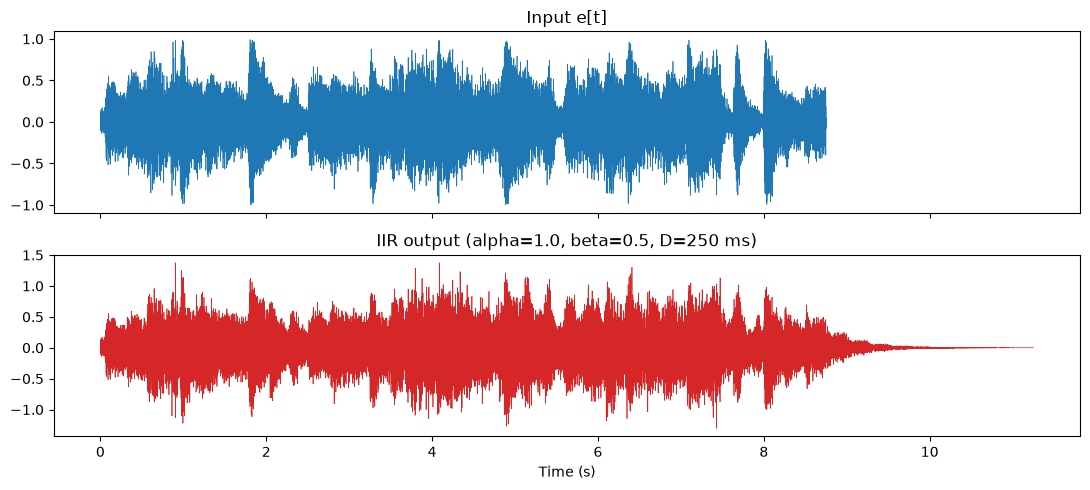

Original:


saved: ../data/outputs/audio/iir_original.wav
IIR delay:


saved: ../data/outputs/audio/iir_delay.wav


'../data/outputs/audio/iir_delay.wav'

In [3]:
def iir_delay(e, alpha, beta, D, tail=None):
    if tail is None:
        # length after which the echoes are below 1e-3 (only meaningful when beta < 1)
        tail = D * int(np.ceil(np.log(1e-3) / np.log(beta))) if 0 < beta < 1 else 6 * D
    x = np.concatenate([e, np.zeros(tail)])
    s = np.zeros(len(x))
    for n0 in range(0, len(x), D):
        blk = slice(n0, min(n0 + D, len(x)))
        prev = s[n0 - D:n0 - D + (blk.stop - blk.start)] if n0 >= D else 0
        s[blk] = alpha * x[blk] + beta * prev
    return s

# check against a plain sample-by-sample loop on a short chunk
x = e[:20000]; ref = np.zeros(len(x))
for n in range(len(x)):
    ref[n] = alpha * x[n] + (beta * ref[n - D] if n >= D else 0)
print('max diff with naive loop:', np.max(np.abs(iir_delay(x, alpha, beta, D, tail=0) - ref)))

s = iir_delay(e, alpha, beta, D)
ts = np.arange(len(s)) / fs
fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ax[0].plot(t, e, lw=.5); ax[0].set_title('Input e[t]')
ax[1].plot(ts, s, lw=.5, color='tab:red'); ax[1].set_title(f'IIR output (alpha={alpha}, beta={beta}, D=250 ms)')
ax[1].set_xlabel('Time (s)'); plt.tight_layout(); plt.show()

print('Original:');   display(Audio(e, rate=fs)); save_audio(e, fs, 'iir_original.wav')
print('IIR delay:');  display(Audio(s / np.max(np.abs(s)), rate=fs)); save_audio(s, fs, 'iir_delay.wav')

## 3. Impulse response (numerical)

Input a unit impulse. Expected: $h[kD] = \alpha\beta^k$, zero elsewhere: an infinite train of echoes that decay over time.

non-zero at t = [    0  4000  8000 12000 16000 20000 24000 28000]
values        = [1.        0.5       0.25      0.125     0.0625    0.03125   0.015625
 0.0078125]
alpha*beta^k  = [1.        0.5       0.25      0.125     0.0625    0.03125   0.015625
 0.0078125]


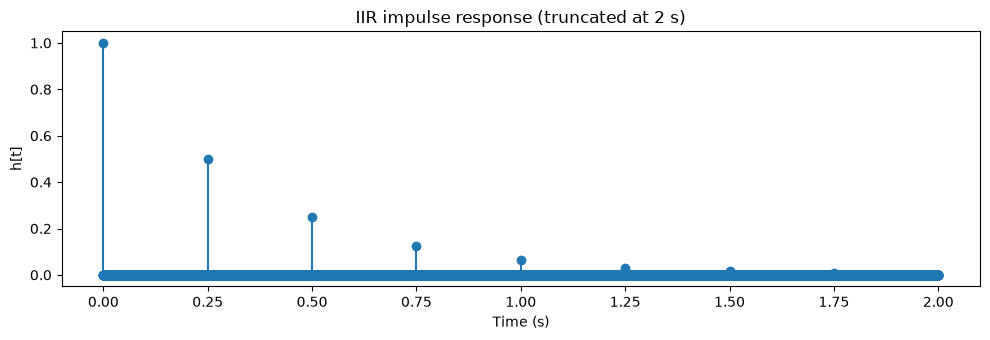

In [4]:
N = 8 * D
delta = np.zeros(N); delta[0] = 1
h = iir_delay(delta, alpha, beta, D, tail=0)

nz = np.nonzero(h)[0]
print('non-zero at t =', nz)
print('values        =', h[nz])
print('alpha*beta^k  =', alpha * beta ** np.arange(len(nz)))

plt.figure(figsize=(10, 3.5))
plt.stem(np.arange(N) / fs, h, basefmt=' ')
plt.xlabel('Time (s)'); plt.ylabel('h[t]'); plt.title('IIR impulse response (truncated at 2 s)')
plt.tight_layout(); plt.show()

## 4. Frequency response (numerical)

The DFT of the impulse response approximates $H(f)$. We use a long truncation so the truncation error is negligible. We expect a Comb filter with peaks $\alpha/(1-\beta)$ at $f = k f_s/D$ and plateaus $\alpha/(1+\beta)$ in between. We display the closed form $\alpha/(1-\beta e^{-j2\pi f D/f_s})$ in order to check.

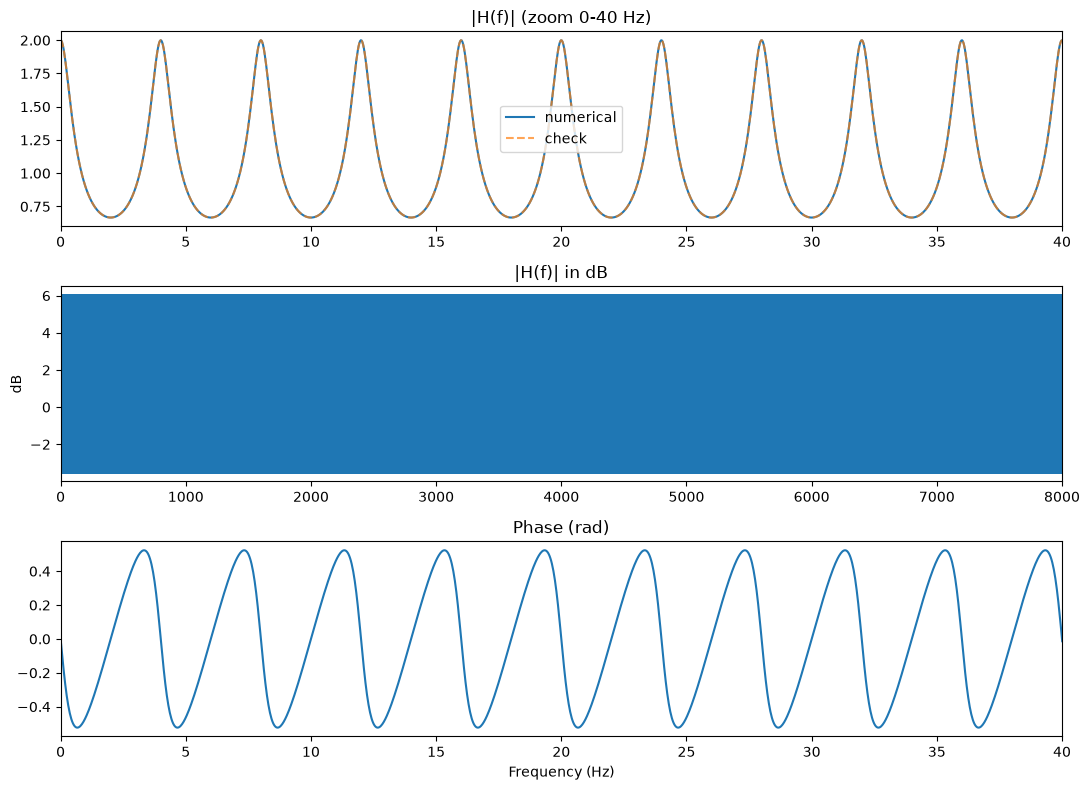

max |H| = 1.9999990463256836  alpha/(1-beta) = 2.0
min |H| = 0.6666669845581055  alpha/(1+beta) = 0.6666666666666666


In [5]:
def impulse_response(alpha, beta, D, n_echo):
    d = np.zeros(n_echo * D + 1); d[0] = 1
    return iir_delay(d, alpha, beta, D, tail=0)

n_echo = int(np.ceil(np.log(1e-6) / np.log(beta)))
h = impulse_response(alpha, beta, D, n_echo)

nfft = 2**19
H = np.fft.rfft(h, nfft)
f = np.fft.rfftfreq(nfft, 1/fs)
H_th = alpha / (1 - beta * np.exp(-2j*np.pi*f*D/fs))

fig, ax = plt.subplots(3, 1, figsize=(11, 8))
ax[0].plot(f, np.abs(H), label='numerical'); ax[0].plot(f, np.abs(H_th), '--', label='check', alpha=.7)
ax[0].set_xlim(0, 40); ax[0].set_title('|H(f)| (zoom 0-40 Hz)'); ax[0].legend()
ax[1].plot(f, 20*np.log10(np.abs(H))); ax[1].set_xlim(0, fs/2); ax[1].set_ylabel('dB'); ax[1].set_title('|H(f)| in dB')
ax[2].plot(f, np.angle(H)); ax[2].set_xlim(0, 40); ax[2].set_title('Phase (rad)'); ax[2].set_xlabel('Frequency (Hz)')
plt.tight_layout(); plt.show()

print('max |H| =', np.abs(H).max(), ' alpha/(1-beta) =', alpha/(1-beta))
print('min |H| =', np.abs(H).min(), ' alpha/(1+beta) =', alpha/(1+beta))

## 5. Stability

The impulse response is $\alpha\beta^k$ at $t=kD$, so it decays if $\beta<1$. For $\beta=1$ echoes never decay, and for $\beta>1$ they grow more and more. 

To insure stability, we need $\beta<1$ and $\alpha$ seems to not affect stability. The sum of $|h|$ (finite iff stable) and the output for a constant input.

beta=0.5: sum|h| over 20 echoes = 2, last echo = 1.91e-06
beta=0.9: sum|h| over 20 echoes = 8.78, last echo = 0.135
beta=1.0: sum|h| over 20 echoes = 20, last echo = 1
beta=1.05: sum|h| over 20 echoes = 33.1, last echo = 2.53


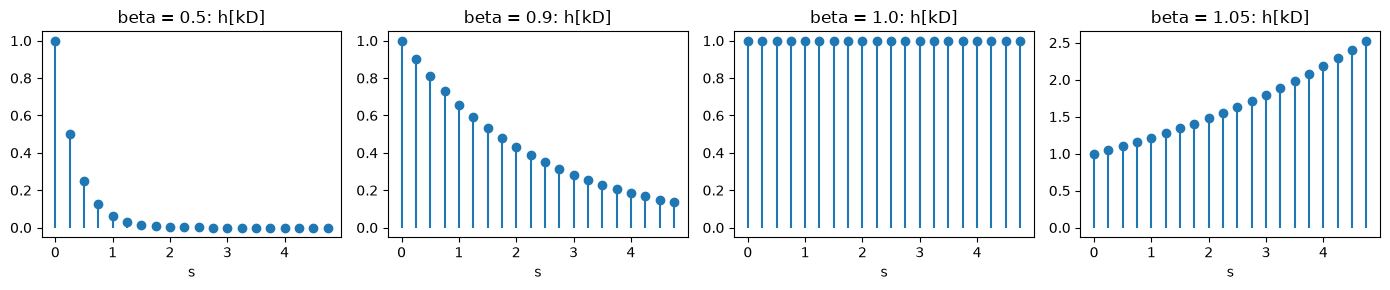

beta=0.5: constant input -> max |output| = 2  (limit 1/(1-beta) = 2)
beta=0.9: constant input -> max |output| = 10  (limit 1/(1-beta) = 10)
beta=1.0: constant input -> max |output| = 200  (limit 1/(1-beta) = inf)
beta=1.05: constant input -> max |output| = 3.458e+05  (limit 1/(1-beta) = inf)


In [7]:
betas = [0.5, 0.9, 1.0, 1.05]
fig, ax = plt.subplots(1, len(betas), figsize=(14, 3), sharey=False)
for a, b in zip(ax, betas):
    hb = iir_delay(np.eye(1, 20*D, 0)[0], 1.0, b, D, tail=0)
    a.stem(np.arange(0, 20*D, D)/fs, hb[::D], basefmt=' '); a.set_title(f'beta = {b}: h[kD]'); a.set_xlabel('s')
    print(f'beta={b}: sum|h| over 20 echoes = {np.abs(hb).sum():.3g}, last echo = {hb[19*D]:.3g}')
plt.tight_layout(); plt.show()

for b in betas:
    y = iir_delay(np.ones(200*D), 1.0, b, D, tail=0)
    print(f'beta={b}: constant input -> max |output| = {np.abs(y).max():.4g}  (limit 1/(1-beta) = {1/(1-b) if b<1 else float("inf"):.4g})')

## 6. Parameters

- For **D**, we can make the same remark as for FIR. A few ms gives a small repetion of notes, 50-100 ms slapback, and >150 ms distinct echoes.
- **$\beta$** insures the decay of the echoes and more importantly the stability (iif $\beta<1$). Closer to 1 means longer, more "reverberant" tail and sharper/taller Comb peaks ($\alpha/(1-\beta)$).
- **$\alpha$** is apure gain on the whole output (it multiplies $h$),and it DOESN'T change the shape. $\alpha=1$ gives the direct sound, but the echoes add up, so the output is actually louder than the input. $\alpha<1$ gives quieter output. Finally, $\alpha>1$ is much louder.

Let us compare $\alpha=1$, $<1$, $>1$ and several $\beta$.

alpha=1.0, beta=0.5: peak of output = 1.37 (input peak 1.0)


saved: ../data/outputs/audio/iir_delay_a1.0_b0.5.wav
alpha=0.5, beta=0.5: peak of output = 0.69 (input peak 1.0)


saved: ../data/outputs/audio/iir_delay_a0.5_b0.5.wav
alpha=2.0, beta=0.5: peak of output = 2.75 (input peak 1.0)


saved: ../data/outputs/audio/iir_delay_a2.0_b0.5.wav
alpha=1.0, beta=0.8: peak of output = 2.07 (input peak 1.0)


saved: ../data/outputs/audio/iir_delay_a1.0_b0.8.wav
alpha=0.2, beta=0.8: peak of output = 0.41 (input peak 1.0)


saved: ../data/outputs/audio/iir_delay_a0.2_b0.8.wav


/tmp/ipykernel_69558/2430299828.py:13: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout(); plt.show()
/home/volodya-ubuntu24/git-folders/M2_Signal_Processing/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


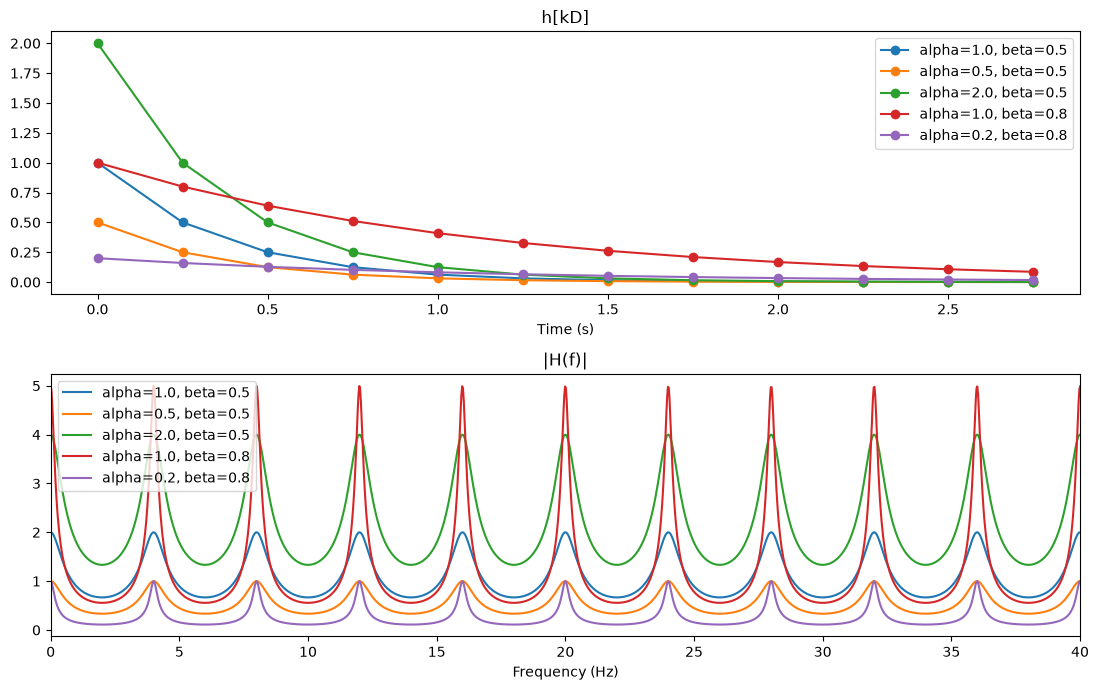

In [8]:
configs = [(1.0, 0.5), (0.5, 0.5), (2.0, 0.5), (1.0, 0.8), (0.2, 0.8)]   # (alpha, beta)
fig, ax = plt.subplots(2, 1, figsize=(11, 7))
for a_, b_ in configs:
    hh = impulse_response(a_, b_, D, 40)
    Hh = np.fft.rfft(hh, nfft)
    ax[0].plot(np.arange(0, 12*D, D)/fs, hh[:12*D:D], 'o-', label=f'alpha={a_}, beta={b_}')
    ax[1].plot(f, np.abs(Hh), label=f'alpha={a_}, beta={b_}')
    s_ = iir_delay(e, a_, b_, D)
    print(f'alpha={a_}, beta={b_}: peak of output = {np.abs(s_).max():.2f} (input peak 1.0)')
    display(Audio(s_ / np.max(np.abs(s_)), rate=fs)); save_audio(s_, fs, f'iir_delay_a{a_}_b{b_}.wav')
ax[0].set_title('h[kD]'); ax[0].set_xlabel('Time (s)'); ax[0].legend()
ax[1].set_xlim(0, 40); ax[1].set_title('|H(f)|'); ax[1].set_xlabel('Frequency (Hz)'); ax[1].legend()
plt.tight_layout(); plt.show()

## 7. Comparison with the FIR

FIR: $h = \delta[t] + \alpha_F\delta[t-D]$. IIR: $h[kD] = \alpha\beta^k$.

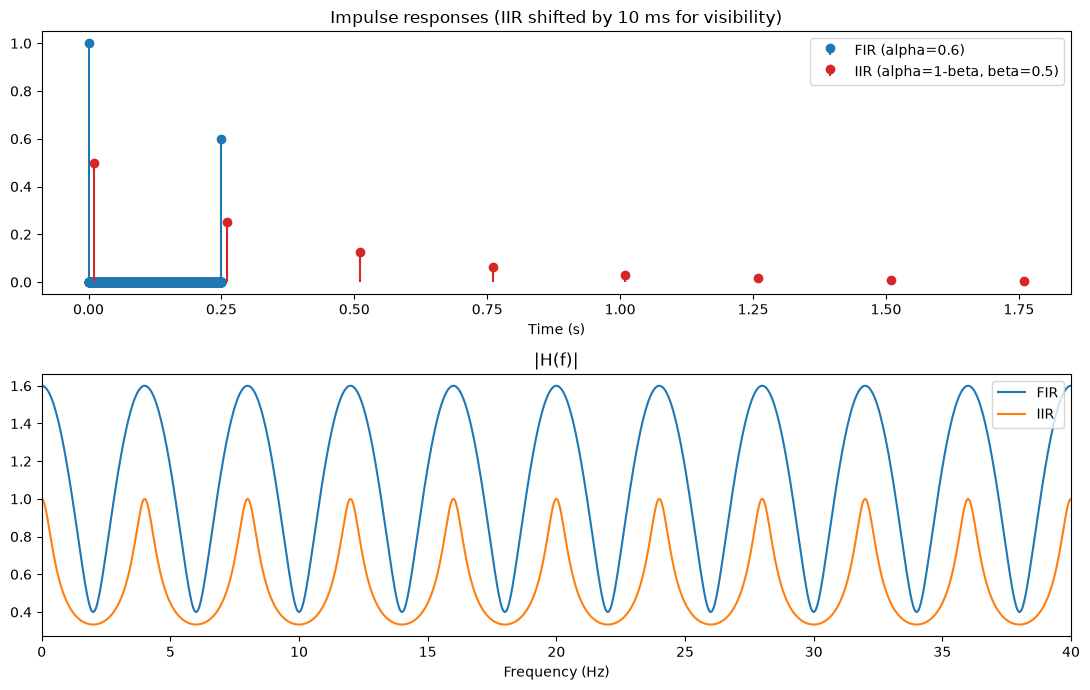

FIR: one echo


saved: ../data/outputs/audio/compare_fir.wav
IIR: repeating echoes


saved: ../data/outputs/audio/compare_iir.wav


'../data/outputs/audio/compare_iir.wav'

In [9]:
alpha_F = 0.6
hF = np.zeros(D + 1)
hF[0] = 1
hF[D] = alpha_F

HF = np.fft.rfft(hF, nfft)
hI = impulse_response(1 - beta, beta, D, n_echo)      # alpha = 1-beta: peak gain 1
HI = np.fft.rfft(hI, nfft)

fig, ax = plt.subplots(2, 1, figsize=(11, 7))
ax[0].stem(np.arange(len(hF))/fs, hF, linefmt='C0-', markerfmt='C0o', basefmt=' ', label='FIR (alpha=0.6)')
ax[0].stem(np.arange(0, 8*D, D)/fs + 0.01, hI[:8*D:D], linefmt='C3-', markerfmt='C3o', basefmt=' ', label='IIR (alpha=1-beta, beta=0.5)')
ax[0].set_title('Impulse responses (IIR shifted by 10 ms for visibility)'); ax[0].legend(); ax[0].set_xlabel('Time (s)')
ax[1].plot(f, np.abs(HF), label='FIR'); ax[1].plot(f, np.abs(HI), label='IIR')
ax[1].set_xlim(0, 40); ax[1].set_title('|H(f)|'); ax[1].set_xlabel('Frequency (Hz)'); ax[1].legend()
plt.tight_layout(); plt.show()

sF = np.zeros(len(e) + D); sF[:len(e)] += e; sF[D:] += alpha_F * e
sI = iir_delay(e, 1 - beta, beta, D)
print('FIR: one echo');            display(Audio(sF / np.max(np.abs(sF)), rate=fs)); save_audio(sF, fs, 'compare_fir.wav')
print('IIR: repeating echoes');    display(Audio(sI / np.max(np.abs(sI)), rate=fs)); save_audio(sI, fs, 'compare_iir.wav')

Having both audios, we can clearly hear the the difference as FIR gives finite echo, while IIR gives a "never ending" echo effect (depending on the beta we choose). 

| | FIR: $s=e[t]+\alpha e[t-D]$ | IIR: $s=\alpha e[t]+\beta s[t-D]$ |
|---|---|---|
| Impulse response | 2 taps | infinite, $\alpha\beta^k$ at $kD$ |
| Sound | a single echo | repeated, decaying echoes (more natural, like a real room) |
| Stability | always stable | only if $\beta<1$ |
| Frequency response | comb, gain in $[1-\alpha,\,1+\alpha]$, smooth peaks | comb, gain in $[\alpha/(1+\beta),\,\alpha/(1-\beta)]$, peaks sharper as $\beta\to1$ |
| Memory / cost | stores the input over $D$ samples | stores the output over $D$ samples (same cost) |
| Notes | cannot blow up, but only one repetition | richer effect for the same memory, but needs care with $\beta$ and output level |

**Conclusion**: with the same delay line, the IIR gives many echoes for the price of one multiplication and one addition per sample, but it is stable only for $\beta<1$ and the gain must be controlled ($\alpha=1-\beta$ keeps the peak gain at 1). The FIR is unconditionally stable but limited to a single echo.